In [1]:
import os
import json
import pickle
from datetime import datetime

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Optimizer
import matplotlib.pyplot as plt
import cmath
import math
from math import e
import time

# Repro
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1785643497.445454  364126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785643497.955598  364126 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785643512.036922  364126 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## **SETTING PARAMETER**

In [2]:
g          = 9.81
d          = 1.0        # kedalaman dasar (m)
a          = 5.0        # wave steepness (m)
h1         = 1.05       # tinggi upstream bore (m)
h2         = 1.0        # tinggi downstream = d (m)
L          = 80    # panjang domain (m)
dx         = 0.1        # spasial (m) sesuai paper
dt_fixed   = 0.01       # timestep fixed (s) sesuai paper
kappa      = 0.5        # artificial viscosity (paper Section 3.1)
dry_tol    = 1e-6
Nx         = int(L / dx) + 1
x_num      = np.linspace(0.0, L, Nx)
 
# Snapshot sesuai Fig.7 paper
save_times = [0.0, 3.19, 6.39, 9.58, 12.77, 15.96]
# save_times = [1.0, 5.0, 10.0, 15.0]
t_end      = max(save_times)
 
XMIN, TMIN = 0.0, 0.0
XMAX, TMAX = L,   t_end

## **OPTIMIZATION METHOD**

### **ADAMW**

In [3]:
# AdamW
class AdamW(Optimizer):
    def __init__(self,
                 learning_rate=0.001, # alpha
                 beta_1=0.9,
                 beta_2=0.999,
                 epsilon=1e-8,
                 weight_decay=0.0,
                 eta_t = None, # Schedule multiplier
                 name="AdamW",**kwargs):
        
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)

        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon
        self.weight_decay = weight_decay

        # eta_t (schedule multiplier)
        if eta_t is None:
            self.eta_t = lambda t: 1.0
        else:
            self.eta_t = eta_t

    def build(self, var_list):
        super().build(var_list)
        # Create slot variables (state)
        self.m = []
        self.v = []

        for var in var_list:
            self.m.append(self.add_variable_from_reference(var, "m"))
            self.v.append(self.add_variable_from_reference(var, "v"))
                
    def update_step(self, grad, var, learning_rate):
        if grad is None:
            return
                
        var_dtype = var.dtype

        lr = tf.cast(learning_rate, var_dtype) # alpha
        beta_1 = tf.cast(self.beta_1, var_dtype)
        beta_2 = tf.cast(self.beta_2, var_dtype)
        epsilon = tf.cast(self.epsilon, var_dtype)
        wd = tf.cast(self.weight_decay, var_dtype)

        index = self._get_variable_index(var)

        m = self.m[index]
        v = self.v[index]

        t = tf.cast(self.iterations + 1, var_dtype)
        eta_t = tf.cast(self.eta_t(self.iterations), var_dtype)

        # Update m and v value
        m.assign(beta_1 * m + (1. - beta_1) * grad)
        v.assign(beta_2 * v + (1. - beta_2) * tf.square(grad))

        # Bias correction
        m_hat = m / (1. - tf.pow(beta_1, t))
        v_hat = v / (1. - tf.pow(beta_2, t))

        # update parameter
        var.assign_sub(eta_t * lr * m_hat / (tf.sqrt(v_hat) + epsilon))

        if self.weight_decay > 0:
            var.assign_sub(eta_t * lr * wd * var)

    def get_config(self):
        return {
            "learning_rate": self.learning_rate,
            "beta_1": self.beta_1,
            "beta_2": self.beta_2,
            "epsilon": self.epsilon,
            "weight_decay": self.weight_decay,
        }

## **LBFGS**

In [4]:
class LBFGS:
    def __init__(self, max_iter=500, m=10, tol=1e-8,
                 c1=1e-4, c2=0.9, max_ls=30, max_zoom=60, ys_min=1e-10,
                 alpha_max=1e4):
        self.max_iter = max_iter   # number of iterations
        self.m = m                 # memory size
        self.tol = tol             # tolerance ||grad||
        self.c1 = c1               # Armijo (sufficient decrease)
        self.c2 = c2               # curvature condition (0.9 for quasi-Newton)
        self.max_ls = max_ls       # max. main phase trial
        self.max_zoom = max_zoom   # max. trial zoom phase
        self.ys_min = ys_min       # additional curvature threshold (safety net)
        self.alpha_max = alpha_max # step size expansion limit

        # --- pembukuan ---
        self.loss_history = []     # ACCEPTED step loss (1 point/iteration)
        self.accept_nfev = []      # position of total nfev when iteration is accepted
        self.nfev_grad = 0         # logged evaluations (loss+gradient), 1 per iteration
        self.nfev_plain = 0        # candidate line search evaluations (loss+gradient)
        self.status = "not_started"
        self.n_iter_done = 0
        self._warned_none_grad = False

    # ---------------- utility ----------------
    @property
    def nfev_total(self):
        return self.nfev_grad + self.nfev_plain

    def pack(self, var_list):
        return tf.concat([tf.reshape(v, [-1]) for v in var_list], axis=0)

    def unpack(self, flat, var_list):
        idx = 0
        for v in var_list:
            size = int(np.prod(v.shape))
            v.assign(tf.reshape(flat[idx:idx + size], v.shape))
            idx += size

    # ---------------- evaluation ----------------
    def _eval(self, var_list, loss_like, counter):
        if counter == "grad":
            self.nfev_grad += 1
        else:
            self.nfev_plain += 1
        with tf.GradientTape() as tape:
            loss = loss_like()
        grads = tape.gradient(loss, var_list)
        if any(g is None for g in grads) and not self._warned_none_grad:
            print("[LBFGS] WARNING: there are None gradients -> possible variable "
                  "disconnected from loss computation (replaced with zeros).")
            self._warned_none_grad = True
        grads = [tf.zeros_like(v) if g is None else g
                 for g, v in zip(grads, var_list)]
        return loss, self.pack(grads)

    def loss_and_grad(self, var_list, loss_fn):
        """logged evaluation: used ONCE per iteration (accepted point)."""
        return self._eval(var_list, loss_fn, counter="grad")

    def _trial_eval(self, theta, p, alpha, var_list, loss_plain):
        """Evaluate line search candidate (without logging)."""
        self.unpack(theta + alpha * p, var_list)
        loss, grad = self._eval(var_list, loss_plain, counter="plain")
        return float(loss), grad, float(tf.tensordot(grad, p, axes=1))

    # ---------------- two-loop recursion ----------------
    def two_loop(self, grad, s_list, y_list):
        q = tf.identity(grad)
        alpha = []
        for i in reversed(range(len(s_list))):
            s, y = s_list[i], y_list[i]
            rho = 1.0 / tf.tensordot(y, s, axes=1)
            a = rho * tf.tensordot(s, q, axes=1)
            alpha.append(a)
            q = q - a * y
        if len(s_list) > 0:      # H0 = gamma * I
            s_last, y_last = s_list[-1], y_list[-1]
            gamma = (tf.tensordot(s_last, y_last, axes=1)
                     / tf.tensordot(y_last, y_last, axes=1))
        else:
            gamma = 1.0
        r = gamma * q
        for i in range(len(s_list)):
            s, y = s_list[i], y_list[i]
            rho = 1.0 / tf.tensordot(y, s, axes=1)
            b = rho * tf.tensordot(y, r, axes=1)
            r = r + s * (alpha[len(s_list) - 1 - i] - b)
        return -r

    # ---------------- strong Wolfe line search ----------------
    def line_search(self, theta, p, loss_val, gTp, var_list, loss_plain):
        """Return (alpha, ok). gTp < 0 must be guaranteed by the caller.
        Implementation of Alg. 3.5: main phase with alpha expansion up to alpha_max,
        each failure enters the zoom phase."""
        phi0, dphi0 = loss_val, gTp
        a_prev, phi_prev = 0.0, phi0
        a = 1.0                      
        for i in range(self.max_ls):
            phi, _, dphi = self._trial_eval(theta, p, a, var_list, loss_plain)

            # non-finite (NaN/Inf) considered as Armijo failure -> narrow bracket
            armijo_ok = math.isfinite(phi) and (phi <= phi0 + self.c1 * a * dphi0)
            if (not armijo_ok) or (i > 0 and phi >= phi_prev):
                return self._zoom(theta, p, phi0, dphi0, var_list, loss_plain,
                                  a_prev, phi_prev, None, a, phi)
            if abs(dphi) <= -self.c2 * dphi0:
                return a, True
            if dphi >= 0:
                return self._zoom(theta, p, phi0, dphi0, var_list, loss_plain,
                                  a, phi, dphi, a_prev, phi_prev)
            # curvature is not sufficient & still decreasing -> EXPANSION (not a failure)
            a_prev, phi_prev = a, phi
            a = min(2.0 * a, self.alpha_max)
            if a >= self.alpha_max:
                break
        self.unpack(theta, var_list)         # ensure clean state
        return 0.0, False

    def _zoom(self, theta, p, phi0, dphi0, var_list, loss_plain,
              lo, lo_phi, lo_dphi, hi, hi_phi):
        for _ in range(self.max_zoom):
            span = hi - lo
            if abs(span) < 1e-16:
                return 0.0, False
            # numerical quadratic interpolation from phi(lo), phi(hi), phi'(lo) if available
            a_j = None
            if lo_dphi is not None:
                denom = 2.0 * (hi_phi - lo_phi - lo_dphi * span)
                if denom != 0.0 and math.isfinite(denom):
                    cand = lo - lo_dphi * span**2 / denom
                    if min(lo, hi) < cand < max(lo, hi) and math.isfinite(cand):
                        a_j = cand
            if a_j is None:
                a_j = 0.5 * (lo + hi)

            phi_j, _, dphi_j = self._trial_eval(theta, p, a_j, var_list, loss_plain)

            fail_hi = ((not math.isfinite(phi_j))
                       or phi_j > phi0 + self.c1 * a_j * dphi0
                       or phi_j >= lo_phi)
            if fail_hi:
                hi, hi_phi = a_j, phi_j
            else:
                if abs(dphi_j) <= -self.c2 * dphi0:
                    return a_j, True
                if dphi_j * (hi - lo) >= 0:
                    hi, hi_phi = lo, lo_phi
                lo, lo_phi, lo_dphi = a_j, phi_j, dphi_j
        return 0.0, False

    # ---------------- main loop ----------------
    def minimize(self, var_list, loss_fn, loss_plain=None):
        """
        loss_fn    : callable -> scalar loss; dievaluasi logged SEKALI per iterasi
                     (boleh berisi log_history/counter).
        loss_plain : callable -> scalar loss TANPA logging/counter; dipakai
                     untuk semua kandidat line search. WAJIB utk kurva bersih.
        """
        if loss_plain is None:
            print("[LBFGS] WARNING: loss_plain is not provided -> line search candidates "
                  "will be logged if loss_fn contains logging.")
            loss_plain = loss_fn

        theta = self.pack(var_list)
        s_list, y_list = [], []
        self.loss_history, self.accept_nfev = [], []

        loss, grad = self.loss_and_grad(var_list, loss_fn)

        for k in range(self.max_iter):
            gnorm = float(tf.norm(grad))
            if gnorm < self.tol:
                self.status = f"converged (||grad||={gnorm:.2e} < tol)"
                print(f"[LBFGS] {self.status} on iteration {k}")
                break

            p = self.two_loop(grad, s_list, y_list)

            # descent direction guardian + memory reset
            gTp = float(tf.tensordot(grad, p, axes=1))
            if (not math.isfinite(gTp)) or gTp >= 0.0:
                p = -grad
                gTp = -float(tf.tensordot(grad, grad, axes=1))
                s_list, y_list = [], []

            alpha, ok = self.line_search(theta, p, float(loss), gTp,
                                         var_list, loss_plain)
            if not ok:
                self.status = (f"line search failed to satisfy strong Wolfe "
                               f"on iteration {k} (consider float64)")
                print(f"[LBFGS] {self.status}")
                self.unpack(theta, var_list)   # ensure clean state
                break

            theta_old = theta
            theta = theta + alpha * p
            self.unpack(theta, var_list)
            loss_new, grad_new = self.loss_and_grad(var_list, loss_fn)
            self.loss_history.append(float(loss_new))
            self.accept_nfev.append(self.nfev_total)

            s = theta - theta_old
            y = grad_new - grad
            ys = float(tf.tensordot(y, s, axes=1))
            if math.isfinite(ys) and ys > self.ys_min:
                s_list.append(s)
                y_list.append(y)
                if len(s_list) > self.m:
                    s_list.pop(0)
                    y_list.pop(0)

            loss, grad = loss_new, grad_new
            self.n_iter_done = k + 1

            if k % 10 == 0:
                print(f"[LBFGS] iter {k:4d} | loss {float(loss_new):.3e} | "
                      f"alpha {alpha:.2e} | ||g|| {gnorm:.3e} | m={len(s_list)}")
        else:
            self.status = "max_iter tercapai"

        print(f"[LBFGS] finished: status='{self.status}', iteration={self.n_iter_done}, "
              f"NFe(grad)={self.nfev_grad}, NFe(plain)={self.nfev_plain}, "
              f"NFe(total)={self.nfev_total}")
        return theta

## **SOLUSI NUMERIK**

In [5]:
def central_diff1(f):
    df = np.zeros_like(f)
    df[1:-1] = (f[2:] - f[:-2]) / (2.*dx)
    df[0]    = (-3.*f[0] + 4.*f[1]  - f[2])  / (2.*dx)
    df[-1]   = ( 3.*f[-1] - 4.*f[-2] + f[-3]) / (2.*dx)
    return df
 
def central_diff2(f):
    d2 = np.zeros_like(f)
    d2[1:-1] = (f[2:] - 2.*f[1:-1] + f[:-2]) / (dx**2)
    d2[0]    = d2[1];  d2[-1] = d2[-2]
    return d2
 
def compute_T(h, u):
    """
    T = u²h + gh²/2 + B2 + B3
    B1 tidak diikutkan karena tidak stabil untuk dx=0.1, dt=0.01.
    """
    du  = central_diff1(u)
    d2u = central_diff2(u)
    B2  = -(h**3 / 3.) * u * d2u
    B3  =  (h**3 / 3.) * (du**2)
    return u**2*h + 0.5*g*h**2 + B2 + B3
 
def art_visc(h, u):
    """Artificial viscosity kappa=0.5 (paper [24])."""
    hn = h.copy(); un = u.copy()
    hn[1:-1] += kappa*0.25*(h[2:] - 2.*h[1:-1] + h[:-2])
    un[1:-1] += kappa*0.25*(u[2:] - 2.*u[1:-1] + u[:-2])
    return hn, un
 
def step_modified_mc(h, u, dt_v):
    """
    MacCormack predictor-corrector dengan B2,B3.
    BC: u=0 di kedua boundary, Neumann h.
    """
    q  = h * u
    T  = compute_T(h, u)
 
    # Predictor (forward diff sesuai paper)
    hp       = h.copy();  up = u.copy()
    hp[:-1]  = h[:-1] + (dt_v/dx)*(q[:-1] - q[1:])
    hp       = np.maximum(hp, dry_tol)
    up[:-1]  = (q[:-1] + (dt_v/dx)*(T[:-1] - T[1:])) / np.maximum(hp[:-1], dry_tol)
    up[0]    = 0.;  up[-1]  = 0.
    hp[0]    = hp[1]; hp[-1] = hp[-2]
 
    # Corrector (backward diff sesuai paper)
    qp       = hp * up
    Tp       = compute_T(hp, up)
    hc       = hp.copy(); uc = up.copy()
    hc[1:]   = hp[1:] + (dt_v/dx)*(-qp[1:] + qp[:-1])
    hc       = np.maximum(hc, dry_tol)
    uc[1:]   = (qp[1:] + (dt_v/dx)*(-Tp[1:] + Tp[:-1])) / np.maximum(hc[1:], dry_tol)
    uc[0]    = 0.;  uc[-1]  = 0.
    hc[0]    = hc[1]; hc[-1] = hc[-2]
 
    # Average + artificial viscosity (paper Section 3.1)
    hbar     = np.maximum(0.5*(h + hc), dry_tol)
    ubar     = 0.5*(u + uc)
    hbar, ubar = art_visc(hbar, ubar)
    hbar     = np.maximum(hbar, dry_tol)
    return hbar, ubar
 
def solve_undular_bore(h_init, u_init, t_final, save_times):
    """Return dict {t: (h_array, u_array)}"""
    h     = h_init.copy()
    u     = u_init.copy()
    t     = 0.0
    out   = {}
    saved = set()
    if 0.0 in save_times:
        out[0.0] = (h.copy(), u.copy()); saved.add(0.0)
    while t < t_final - 1e-10:
        dt_use = min(dt_fixed, t_final - t)
        h, u   = step_modified_mc(h, u, dt_use)
        t     += dt_use
        for ts in save_times:
            if ts not in saved and abs(t - ts) <= dt_use + 1e-10:
                out[ts] = (h.copy(), u.copy()); saved.add(ts)
    return out

In [6]:
# Initial Condition
h_ic = h2 + (h1 - h2) * 0.5 * (1.0 - np.tanh(x_num / a))
u_ic = np.zeros(Nx)

print(f"IC: h=[{h_ic.min():.4f},{h_ic.max():.4f}] u=0 (konsisten dengan BC)")
print(f"    bore upstream h1={h1}, downstream h2={h2}")
 
# IC PINN identik dengan numerik
x_ic_tf  = tf.constant(x_num.reshape(-1,1).astype(np.float32))
h0_ic_tf = tf.constant(h_ic.reshape(-1,1).astype(np.float32))
u0_ic_tf = tf.constant(u_ic.reshape(-1,1).astype(np.float32))

IC: h=[1.0000,1.0250] u=0 (konsisten dengan BC)
    bore upstream h1=1.05, downstream h2=1.0


I0000 00:00:1785643524.499042  364126 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
t_s        = time.perf_counter()
results_mc = solve_undular_bore(h_ic, u_ic, t_end, save_times)
t_e        = time.perf_counter()
print(f"  Selesai {t_e-t_s:.3f} s, tersimpan t={list(results_mc.keys())}\n")

  Selesai 0.117 s, tersimpan t=[0.0, 3.19, 6.39, 9.58, 12.77, 15.96]



In [9]:
# Data Latih PINN dari Solusi Numerik
x_all_lst, t_all_lst, h_all_lst, u_all_lst = [], [], [], []
for ts in save_times:
    if ts not in results_mc:
        continue
    h_ts, u_ts = results_mc[ts]
    x_all_lst.append(x_num)
    t_all_lst.append(np.full(Nx, ts))
    h_all_lst.append(h_ts)
    u_all_lst.append(u_ts)
 
x_all = np.concatenate(x_all_lst).astype(np.float32)
t_all = np.concatenate(t_all_lst).astype(np.float32)
h_all = np.concatenate(h_all_lst).astype(np.float32)
u_all = np.concatenate(u_all_lst).astype(np.float32)
 
# Subsample 15% acak
N_total   = len(x_all)
idx       = np.random.choice(N_total, size=int(0.15*N_total), replace=False)
x_data_tf = tf.constant(x_all[idx].reshape(-1,1))
t_data_tf = tf.constant(t_all[idx].reshape(-1,1))
h_data_tf = tf.constant(h_all[idx].reshape(-1,1))
u_data_tf = tf.constant(u_all[idx].reshape(-1,1))
 
print(f"  Data numerik: {N_total} titik  subsample {len(idx)} (15%)\n")

  Data numerik: 4806 titik  subsample 720 (15%)



## **SOLUSI PINN**

In [8]:
# Collocotion Point
NT_col, NX_col = 150, 150
t_grid   = np.linspace(TMIN, TMAX, NT_col, dtype=np.float32)
x_grid   = np.linspace(XMIN, XMAX, NX_col, dtype=np.float32)
TT, XX   = np.meshgrid(t_grid, x_grid, indexing='ij')
x_col_tf = tf.constant(XX.reshape(-1,1))
t_col_tf = tf.constant(TT.reshape(-1,1))

In [11]:
def build_mlp(widths=(64,64,64,64), activation='swish'):
    inp = layers.Input(shape=(2,))
    z   = inp
    for w in widths:
        z = layers.Dense(w, activation=activation,
                         kernel_initializer='glorot_normal')(z)
    out = layers.Dense(1, activation='linear')(z)
    return Model(inp, out)
 
h_model = build_mlp()
u_model = build_mlp()
print("  Arsitektur: 2 jaringan 4×64, swish\n")

  Arsitektur: 2 jaringan 4×64, swish



In [12]:
@tf.function
def pde_loss(x, t):
    """Residu Boussinesq penuh (paper eq.1-3)."""
    with tf.GradientTape(persistent=True) as tape3:
        tape3.watch([x, t])
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch([x, t])
            with tf.GradientTape(persistent=True) as tape1:
                tape1.watch([x, t])
                X    = tf.concat([x, t], axis=1)
                h    = h_model(X); u = u_model(X)
                h2   = h**2; h3 = h**3
                uh   = u*h;  u2h = (u**2)*h
            u_x   = tape1.gradient(u,   x); u_t   = tape1.gradient(u,   t)
            h_t   = tape1.gradient(h,   t); uh_x  = tape1.gradient(uh,  x)
            uh_t  = tape1.gradient(uh,  t); h2_x  = tape1.gradient(h2,  x)
            h3_x  = tape1.gradient(h3,  x); u2h_x = tape1.gradient(u2h, x)
            del tape1
        u_xx = tape2.gradient(u_x, x); u_xt = tape2.gradient(u_x, t)
        del tape2
    u_xxx = tape3.gradient(u_xx, x); u_xxt = tape3.gradient(u_xx, t)
    del tape3
 
    B1_x = (-h3_x/3.)*u_xt  - (h3/3.)*u_xxt
    B2_x = (-h3_x/3.)*u*u_xx - (h3/3.)*u_x*u_xx - (h3/3.)*u*u_xxx
    B3_x = (h3_x/3.)*(u_x**2) + (2.*h3/3.)*u_x*u_xx
    R1   = h_t + uh_x
    R2   = uh_t + u2h_x + (g/2.)*h2_x + B1_x + B2_x + B3_x
    return tf.reduce_mean(R1**2 + R2**2)
 
 
def ic_loss():
    t0     = tf.zeros((Nx, 1), dtype=tf.float32)
    X_ic   = tf.concat([x_ic_tf, t0], axis=1)
    return (tf.reduce_mean((h_model(X_ic) - h0_ic_tf)**2) +
            tf.reduce_mean((u_model(X_ic) - u0_ic_tf)**2))
 
 
@tf.function
def bc_loss(n_pts=100):
    t_bc    = tf.random.uniform((n_pts, 1), TMIN, TMAX)
    x_left  = tf.zeros((n_pts, 1), dtype=tf.float32)
    x_right = tf.fill((n_pts, 1), float(L))
    u_left  = u_model(tf.concat([x_left,  t_bc], axis=1))
    u_right = u_model(tf.concat([x_right, t_bc], axis=1))
    loss_u  = tf.reduce_mean(u_left**2) + tf.reduce_mean(u_right**2)
    with tf.GradientTape(persistent=True) as tp:
        tp.watch([x_left, x_right])
        h_l = h_model(tf.concat([x_left,  t_bc], axis=1))
        h_r = h_model(tf.concat([x_right, t_bc], axis=1))
    loss_h = tf.reduce_mean(tp.gradient(h_l, x_left)**2) + \
             tf.reduce_mean(tp.gradient(h_r, x_right)**2)
    del tp
    return loss_u + loss_h
 
 
def data_loss_fn():
    X_d = tf.concat([x_data_tf, t_data_tf], axis=1)
    return (tf.reduce_mean((h_model(X_d) - h_data_tf)**2) +
            tf.reduce_mean((u_model(X_d) - u_data_tf)**2))
 
 
def total_loss(lambda_pde=1.0, lambda_ic=10.0,
               lambda_bc=5.0,  lambda_data=1.0):
    lp   = pde_loss(x_col_tf, t_col_tf)
    lic  = ic_loss()
    lbc  = bc_loss()
    ldat = data_loss_fn()
    tot  = lambda_pde*lp + lambda_ic*lic + lambda_bc*lbc + lambda_data*ldat
    return tot, lp, lic, lbc, ldat

## **TRAIN PINN**

In [13]:
# ============================================================
# Output folder
# ============================================================
BASE_DIR = r"/mnt/d/PINN Research_Iwan/CodeBaru/best_models"

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(BASE_DIR, f"baseline_undular_adamw_adamw_{run_id}")

model_dir = os.path.join(save_dir, "models")
fig_dir = os.path.join(save_dir, "figures")

os.makedirs(model_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print("=" * 58)
print("  Output folder")
print("=" * 58)
print(f"  save_dir : {save_dir}")
print(f"  model_dir: {model_dir}")
print(f"  fig_dir  : {fig_dir}")


# ============================================================
# Prepare trainable variables and history
# ============================================================
vars_list = h_model.trainable_variables + u_model.trainable_variables

history = {
    k: [] for k in [
        "step",
        "epoch",
        "phase",
        "total",
        "pde",
        "ic",
        "bc",
        "data"
    ]
}


def to_float(x):
    return float(x.numpy() if hasattr(x, "numpy") else x)


def log_history(vals, step, epoch, phase):
    keys = ["total", "pde", "ic", "bc", "data"]

    history["step"].append(int(step))
    history["epoch"].append(int(epoch))
    history["phase"].append(phase)

    for k, v in zip(keys, vals):
        history[k].append(to_float(v))


# ============================================================
# Training configuration
# ============================================================
epochs_phase1 = 1000
epochs_phase2 = 500

lr_phase1 = 1e-3
lr_phase2 = 1e-4

wd_phase1 = 1e-4
wd_phase2 = 1e-5


print("=" * 58)
print("  Step 2: Training PINN")
print("=" * 58)

t0_train = time.perf_counter()


# ============================================================
# Phase 1: AdamW
# ============================================================
opt1 = AdamW(
    learning_rate=lr_phase1,
    weight_decay=wd_phase1
)

print(f"  [Fase 1] AdamW  lr={lr_phase1:.1e}  wd={wd_phase1:.1e}  {epochs_phase1} epoch")

for epoch in range(1, epochs_phase1 + 1):
    with tf.GradientTape() as tape:
        loss, lp, lic, lbc, ldat = total_loss()

    grads = tape.gradient(loss, vars_list)
    opt1.apply_gradients(zip(grads, vars_list))

    global_step = epoch

    log_history(
        [loss, lp, lic, lbc, ldat],
        step=global_step,
        epoch=epoch,
        phase="AdamW-1"
    )

    if epoch % 100 == 0 or epoch == 1:
        print(
            f"  Ep {epoch:5d} | "
            f"Total={to_float(loss):.3e} | "
            f"PDE={to_float(lp):.3e} | "
            f"IC={to_float(lic):.3e} | "
            f"BC={to_float(lbc):.3e} | "
            f"Data={to_float(ldat):.3e}"
        )


# ============================================================
# Phase 2: AdamW fine-tuning
# ============================================================
opt2 = AdamW(
    learning_rate=lr_phase2,
    weight_decay=wd_phase2
)

print(f"\n  [Fase 2] AdamW  lr={lr_phase2:.1e}  wd={wd_phase2:.1e}  {epochs_phase2} epoch fine-tune")

for epoch in range(1, epochs_phase2 + 1):
    with tf.GradientTape() as tape:
        loss, lp, lic, lbc, ldat = total_loss()

    grads = tape.gradient(loss, vars_list)
    opt2.apply_gradients(zip(grads, vars_list))

    global_step = epochs_phase1 + epoch

    log_history(
        [loss, lp, lic, lbc, ldat],
        step=global_step,
        epoch=epoch,
        phase="AdamW-2"
    )

    if epoch % 100 == 0 or epoch == 1:
        print(
            f"  Ep {epoch:5d} | "
            f"Total={to_float(loss):.3e} | "
            f"PDE={to_float(lp):.3e} | "
            f"IC={to_float(lic):.3e} | "
            f"BC={to_float(lbc):.3e} | "
            f"Data={to_float(ldat):.3e}"
        )


# ============================================================
# Final evaluation
# ============================================================
loss, lp, lic, lbc, ldat = total_loss()

final_step = epochs_phase1 + epochs_phase2 + 1

log_history(
    [loss, lp, lic, lbc, ldat],
    step=final_step,
    epoch=0,
    phase="Final"
)

t1_train = time.perf_counter()
training_time = float(t1_train - t0_train)

print(f"\n  Final evaluation:")
print(
    f"  Total={to_float(loss):.3e} | "
    f"PDE={to_float(lp):.3e} | "
    f"IC={to_float(lic):.3e} | "
    f"BC={to_float(lbc):.3e} | "
    f"Data={to_float(ldat):.3e}"
)

print(f"\n  Total waktu training: {training_time:.1f} s\n")

  Output folder
  save_dir : /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215
  model_dir: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215/models
  fig_dir  : /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215/figures
  Step 2: Training PINN
  [Fase 1] AdamW  lr=1.0e-03  wd=1.0e-04  1000 epoch
  Ep     1 | Total=1.308e+01 | PDE=1.009e-01 | IC=8.398e-01 | BC=7.265e-01 | Data=9.482e-01
  Ep   100 | Total=7.331e-02 | PDE=7.487e-03 | IC=4.622e-03 | BC=3.357e-03 | Data=2.822e-03
  Ep   200 | Total=1.144e-02 | PDE=1.869e-03 | IC=7.075e-04 | BC=3.394e-04 | Data=8.005e-04
  Ep   300 | Total=3.198e-03 | PDE=8.390e-04 | IC=1.414e-04 | BC=9.622e-05 | Data=4.641e-04
  Ep   400 | Total=1.544e-03 | PDE=4.519e-04 | IC=4.696e-05 | BC=6.765e-05 | Data=2.839e-04
  Ep   500 | Total=8.389e-04 | PDE=2.733e-04 | IC=2.404e-05 | BC=2.594e-05 | Data=1.954e-04
  Ep   600 | Total=5.688e

In [14]:
for ts in save_times:
    if ts not in results_mc: continue
    h_mc_ts, u_mc_ts = results_mc[ts]
    X_ts = tf.constant(np.stack([x_num.astype(np.float32),
                                  np.full(Nx, ts, np.float32)], axis=1))
    h_p    = h_model(X_ts).numpy().flatten()
    u_p    = u_model(X_ts).numpy().flatten()
    rmse_h = np.sqrt(np.mean((h_p - h_mc_ts)**2))
    rmse_u = np.sqrt(np.mean((u_p - u_mc_ts)**2))
    print(f"  t={ts:6.2f}s | RMSE h={rmse_h:.6f} m | RMSE u={rmse_u:.6f} m/s")

  t=  0.00s | RMSE h=0.000807 m | RMSE u=0.000701 m/s
  t=  3.19s | RMSE h=0.003453 m | RMSE u=0.007439 m/s
  t=  6.39s | RMSE h=0.004336 m | RMSE u=0.003813 m/s
  t=  9.58s | RMSE h=0.002625 m | RMSE u=0.004362 m/s
  t= 12.77s | RMSE h=0.003720 m | RMSE u=0.004573 m/s
  t= 15.96s | RMSE h=0.003329 m | RMSE u=0.006194 m/s


## **VISUALISASI**

In [9]:
def plot_comparison(results_mc, h_model, x_num, times, save_path=None):

    n = len(times)

    fig, axes = plt.subplots(n, 1, figsize=(10, 3.0*n))

    if n == 1:
        axes = [axes]

    fig.suptitle(
        "Water Depth (h) Comparison — Modified MC vs PINN\n"
        # r"IC: $h(x,0)=h_2+\frac{h_1-h_2}{2}[1-\tanh(x/a)]$"
        # f"   $(h_1={h1}, d={h2}, a={a})$",
        # fontsize=11,
        # fontweight='bold'
    )

    for i, t in enumerate(times):

        ax = axes[i]

        # =========================
        # Data numerik
        # =========================
        if t in results_mc:
            h_num, _ = results_mc[t]
        else:
            closest = min(results_mc.keys(), key=lambda k: abs(k-t))
            h_num, _ = results_mc[closest]

        # =========================
        # Prediksi PINN
        # =========================
        X_tf = tf.constant(
            np.stack([
                x_num.astype(np.float32),
                np.full(len(x_num), t, np.float32)
            ], axis=1)
        )

        h_pinn = h_model(X_tf).numpy().flatten()

        # =========================
        # RMSE
        # =========================
        rmse_h = np.sqrt(np.mean((h_pinn - h_num)**2))

        # =========================
        # Plot h
        # =========================
        ax.plot(
            x_num,
            h_num,
            'b-',
            lw=1.5,
            label='Modified MC'
        )

        ax.plot(
            x_num,
            h_pinn,
            'r--',
            lw=1.2,
            label='PINN'
        )

        ax.set_title(
            f't={t:.2f}s | RMSE h={rmse_h:.5f} m',
            fontsize=9
        )

        ax.set_xlabel('x (m)')
        ax.set_ylabel('h (m)')

        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches='tight'
        )
        print(f"  Plot: {save_path}")

    plt.show()

In [10]:
def plot_loss_history(
    history,
    epochs_phase1=5000,
    save_path=None
):
    """
    Plot riwayat loss untuk baseline AdamW + AdamW.

    Parameters
    ----------
    history       : dict berisi step, phase, total, pde, ic, bc, data
    epochs_phase1 : jumlah epoch fase 1
    save_path     : path file PNG, None jika tidak disimpan
    """

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Loss History — Baseline PINN AdamW-AdamW")

    if "step" in history:
        steps = np.array(history["step"])
    else:
        steps = np.arange(1, len(history["total"]) + 1)

    phase_boundary = epochs_phase1 + 0.5

    # ============================================================
    # Panel kiri: semua komponen loss
    # ============================================================
    ax = axes[0]

    ax.semilogy(steps, history["total"], 'k-',  lw=1.4, label='Total')
    ax.semilogy(steps, history["pde"],   'b--', lw=1.1, label='PDE')
    ax.semilogy(steps, history["ic"],    'g:',  lw=1.1, label='IC')
    ax.semilogy(steps, history["bc"],    'm-',  lw=1.1, label='BC', alpha=0.8)
    ax.semilogy(steps, history["data"],  'r-',  lw=1.1, label='Data')

    ax.axvline(
        phase_boundary,
        color='gray',
        ls=':',
        lw=1,
        label='AdamW-1 → AdamW-2'
    )

    ax.set_xlabel("Training step / Number of Function Evaluations (NFE)")
    ax.set_ylabel("Loss")
    ax.set_title("All Loss Components")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ============================================================
    # Panel kanan: total loss
    # ============================================================
    ax2 = axes[1]

    ax2.semilogy(steps, history["total"], 'k-', lw=1.4)

    ax2.axvline(
        phase_boundary,
        color='gray',
        ls=':',
        lw=1,
        label='AdamW-1 → AdamW-2'
    )

    ax2.set_xlabel("Training Step / Number of Function Evaluations (NFE)")
    ax2.set_ylabel("Total Loss")
    ax2.set_title("Total Loss Convergence")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Figure disimpan: {save_path}")

    plt.show()

  Step 3: Saving trained PINN
  Figure disimpan: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215/figures/loss_history_baseline_adamw_adamw.png


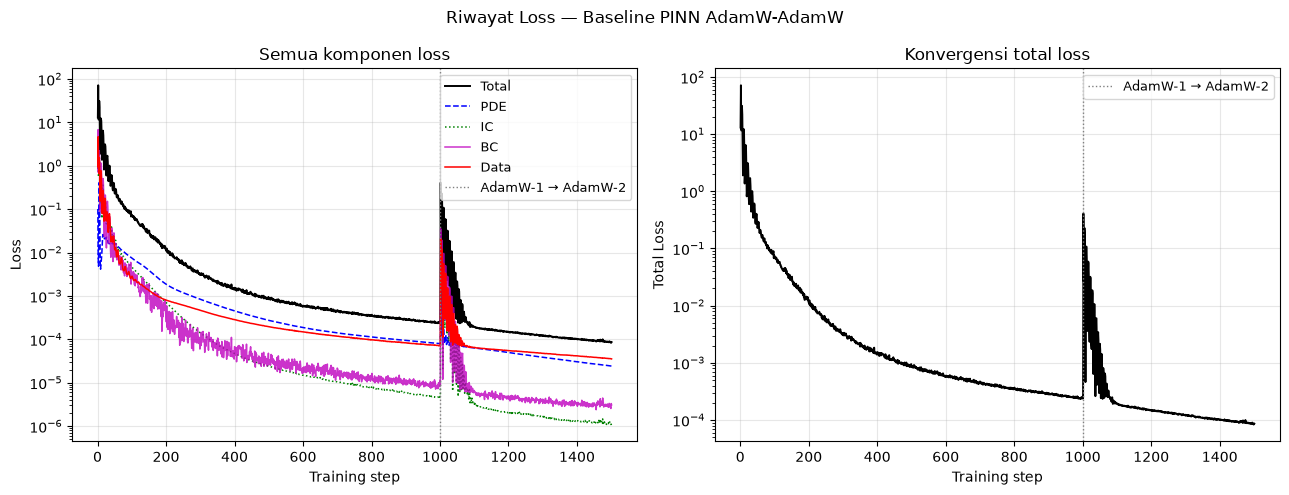

  Output saved to: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215
  - models/h_model.keras
  - models/u_model.keras
  - training_history.pkl
  - config.json
  - figures/loss_history_baseline_adamw_adamw.png


In [17]:
print("=" * 58)
print("  Step 3: Saving trained PINN")
print("=" * 58)

# ============================================================
# Save trained models
# ============================================================
h_model.save(os.path.join(model_dir, "h_model.keras"))
u_model.save(os.path.join(model_dir, "u_model.keras"))

# ============================================================
# Save training history
# ============================================================
history_path = os.path.join(save_dir, "training_history.pkl")

with open(history_path, "wb") as f:
    pickle.dump(history, f)

# ============================================================
# Save figure
# ============================================================
fig_path = os.path.join(fig_dir, "loss_history_baseline_adamw_adamw.png")

plot_loss_history(
    history,
    epochs_phase1=epochs_phase1,
    save_path=fig_path
)

# ============================================================
# Save experiment config
# ============================================================
config = {
    "scheme": "baseline_adamw_adamw",
    "epochs_phase1": epochs_phase1,
    "epochs_phase2": epochs_phase2,
    "learning_rate_phase1": lr_phase1,
    "learning_rate_phase2": lr_phase2,
    "weight_decay_phase1": wd_phase1,
    "weight_decay_phase2": wd_phase2,
    "final_loss": to_float(loss),
    "final_pde": to_float(lp),
    "final_ic": to_float(lic),
    "final_bc": to_float(lbc),
    "final_data": to_float(ldat),
    "training_time_seconds": training_time,
    "save_dir": save_dir,
    "model_dir": model_dir,
    "fig_dir": fig_dir,
}

# Optional vars to include
optional_vars = [
    "XMAX", "TMIN", "TMAX",
    "NT", "NX", "N_f", "N_data",
    "lambda_pde", "lambda_ic", "lambda_bc", "lambda_data",
    "g", "h0", "h1", "h2", "l1", "l2"
]

for name in optional_vars:
    if name in globals():
        val = globals()[name]
        try:
            json.dumps(val)
            config[name] = val
        except TypeError:
            try:
                config[name] = float(val)
            except Exception:
                config[name] = str(val)

config_path = os.path.join(save_dir, "config.json")

with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

print(f"  Output saved to: {save_dir}")
print(f"  - models/h_model.keras")
print(f"  - models/u_model.keras")
print(f"  - training_history.pkl")
print(f"  - config.json")
print(f"  - figures/loss_history_baseline_adamw_adamw.png")

In [11]:
save_dir  = r"/mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215"
model_dir = os.path.join(save_dir, "models")

h_model = tf.keras.models.load_model(os.path.join(model_dir, "h_model.keras"))
u_model = tf.keras.models.load_model(os.path.join(model_dir, "u_model.keras"))
print("Model berhasil dimuat.")


rmse_h_list = []
rmse_u_list = []

print(f"{'t (s)':>8} | {'RMSE h (m)':>12} | {'RMSE u (m/s)':>13}")
print("-" * 40)

for ts in save_times:
    if ts not in results_mc:
        continue

    h_mc_ts, u_mc_ts = results_mc[ts]
    X_ts = tf.constant(np.stack([
        x_num.astype(np.float32),
        np.full(Nx, ts, np.float32)
    ], axis=1))

    h_p = h_model(X_ts).numpy().flatten()
    u_p = u_model(X_ts).numpy().flatten()

    rmse_h = np.sqrt(np.mean((h_p - h_mc_ts) ** 2))
    rmse_u = np.sqrt(np.mean((u_p - u_mc_ts) ** 2))

    rmse_h_list.append(rmse_h)
    rmse_u_list.append(rmse_u)

    print(f"{ts:8.2f} | {rmse_h:12.6f} | {rmse_u:13.6f}")

# Rata-rata RMSE  
mean_rmse_h = np.mean(rmse_h_list)
mean_rmse_u = np.mean(rmse_u_list)

print("-" * 40)
print(f"{'MEAN':>8} | {mean_rmse_h:12.6f} | {mean_rmse_u:13.6f}")

Model berhasil dimuat.
   t (s) |   RMSE h (m) |  RMSE u (m/s)
----------------------------------------
    0.00 |     0.000807 |      0.000701
    3.19 |     0.003453 |      0.007439
    6.39 |     0.004336 |      0.003813
    9.58 |     0.002625 |      0.004362
   12.77 |     0.003720 |      0.004573
   15.96 |     0.003329 |      0.006194
----------------------------------------
    MEAN |     0.003045 |      0.004514


  Figure disimpan: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215/figures/loss_history_en.png


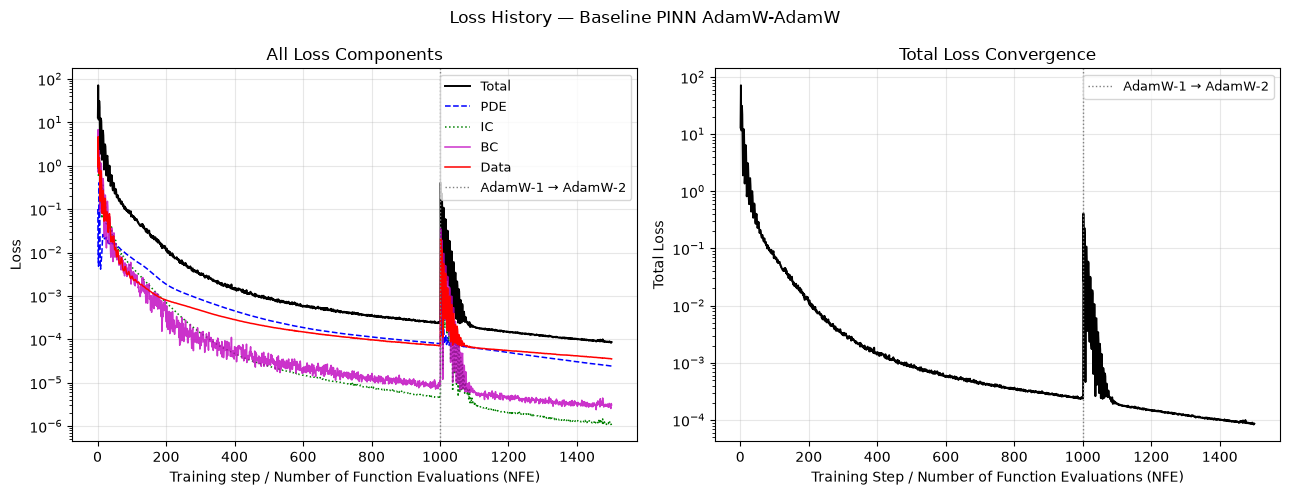

In [12]:
fig_dir  = os.path.join(save_dir, "figures")

# Load History
with open(os.path.join(save_dir, "training_history.pkl"), "rb") as f:
    history = pickle.load(f)

# Plot Loss
plot_loss_history(
    history,
    epochs_phase1=history["phase"].count("AdamW-1"),  
    save_path=os.path.join(fig_dir, "loss_history_en.png")
)

  Plot: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215/figures/hybrid_pinn_h.png


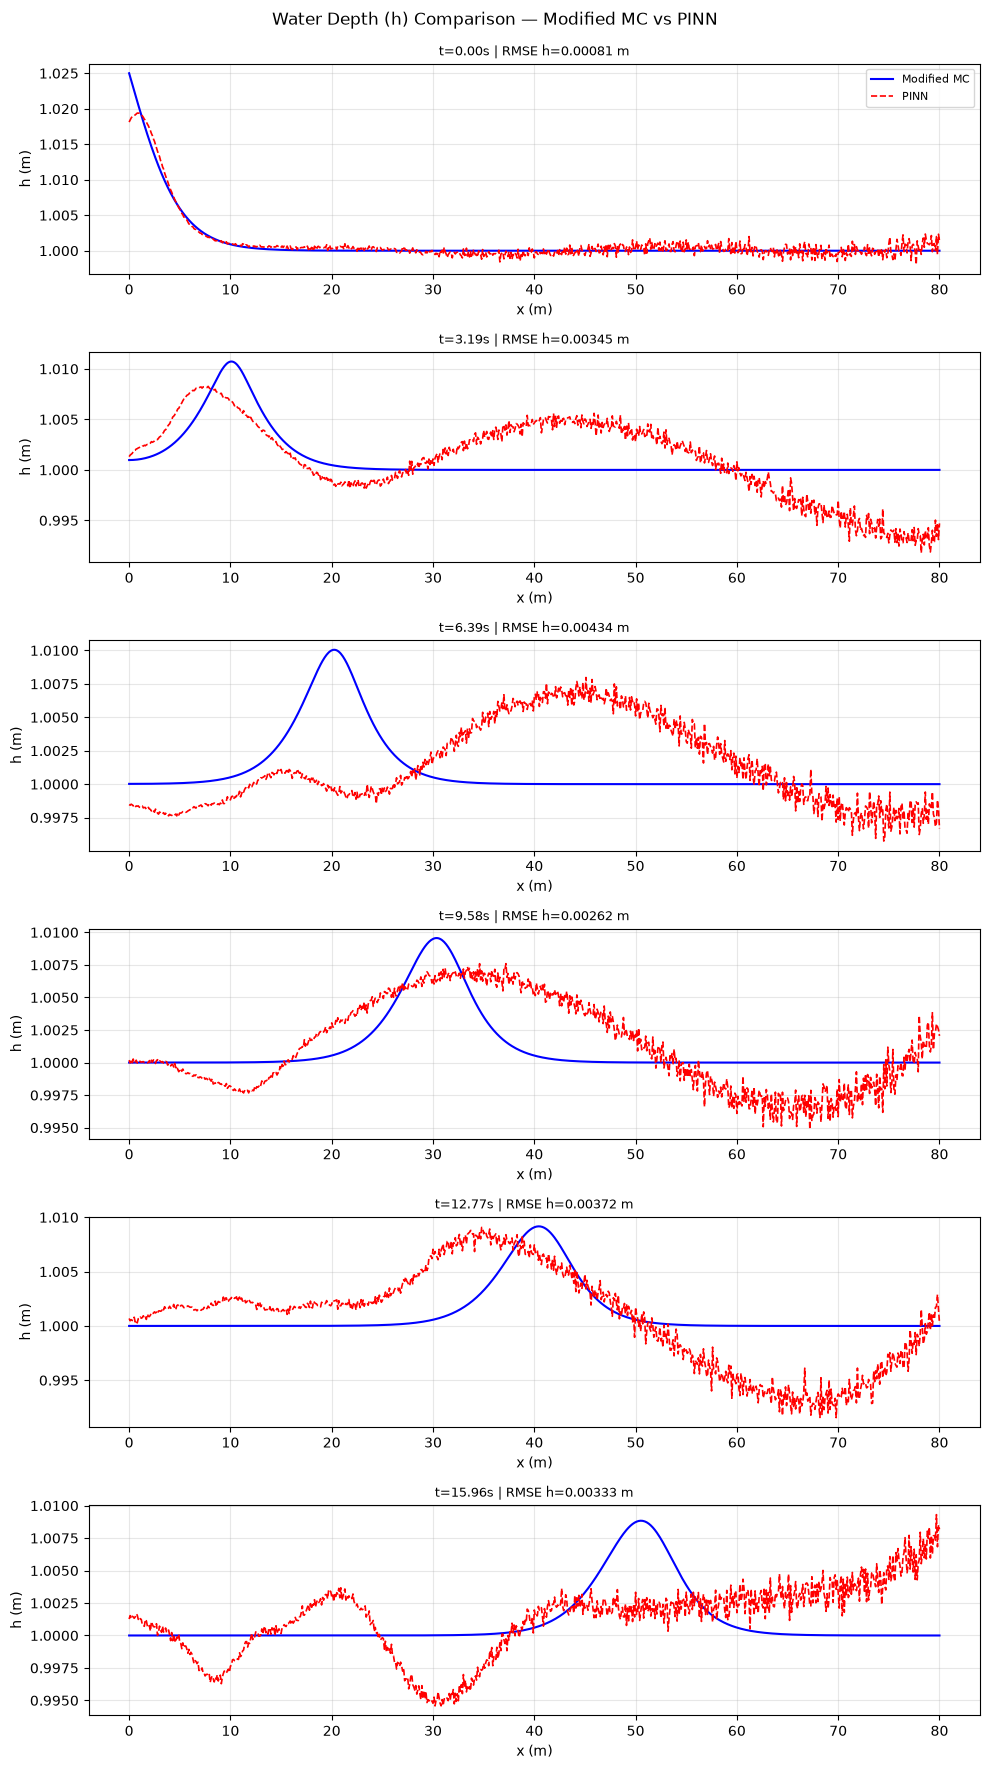

In [15]:
plot_comparison(
    results_mc = results_mc,
    h_model    = h_model,
    x_num      = x_num,
    times      = save_times,
    save_path  = os.path.join(fig_dir, "hybrid_pinn_h.png")
)

In [13]:
def plot_comparison_u_undular(
    results_mc,
    u_model,
    x_num,
    times,
    save_path=None
):
    """
    Perbandingan flow velocity u antara Modified MC dan PINN
    untuk kasus undular bore di semua snapshot waktu.

    Parameters
    ----------
    results_mc : dict
        Dictionary hasil Modified MC.
        Diasumsikan:
        results_mc[t] = (h_num, u_num)

    u_model : tf.keras.Model
        Model PINN untuk prediksi velocity u.

    x_num : array-like
        Grid spasial.

    times : list or array-like
        Daftar waktu snapshot yang ingin diplot.

    save_path : str or None
        Path untuk menyimpan gambar.
    """

    n = len(times)

    fig, axes = plt.subplots(n, 1, figsize=(10, 3.0 * n))

    if n == 1:
        axes = [axes]

    fig.suptitle(
        "Flow Velocity (u) Comparison — Modified MC vs PINN\n"
    )

    for i, t in enumerate(times):

        ax = axes[i]

        # =========================
        # Data numerik Modified MC
        # =========================
        if t in results_mc:
            _, u_num = results_mc[t]
            t_used = t
        else:
            closest = min(results_mc.keys(), key=lambda k: abs(k - t))
            _, u_num = results_mc[closest]
            t_used = closest
            print(f"  [peringatan] t={t} tidak tersedia, pakai t={closest}")

        # =========================
        # Prediksi PINN
        # =========================
        X_tf = tf.constant(
            np.stack(
                [
                    x_num.astype(np.float32),
                    np.full(len(x_num), t_used, dtype=np.float32)
                ],
                axis=1
            )
        )

        u_pinn = u_model(X_tf).numpy().flatten()

        # =========================
        # RMSE
        # =========================
        rmse_u = np.sqrt(np.mean((u_pinn - u_num) ** 2))

        # =========================
        # Plot u
        # =========================
        ax.plot(
            x_num,
            u_num,
            'b-',
            lw=1.5,
            label='Modified MC'
        )

        ax.plot(
            x_num,
            u_pinn,
            'r--',
            lw=1.2,
            label='PINN'
        )

        ax.set_title(
            f't={t_used:.2f}s | RMSE u={rmse_u:.5f} m/s',
            fontsize=9
        )

        ax.set_xlabel('x (m)')
        ax.set_ylabel('u (m/s)')

        ax.grid(True, alpha=0.3)

        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches='tight'
        )
        print(f"  Plot: {save_path}")

    plt.show()

  Plot: /mnt/d/PINN Research_Iwan/CodeBaru/best_models/baseline_undular_adamw_adamw_20260706_100215/figures/hybrid_pinn_u.png


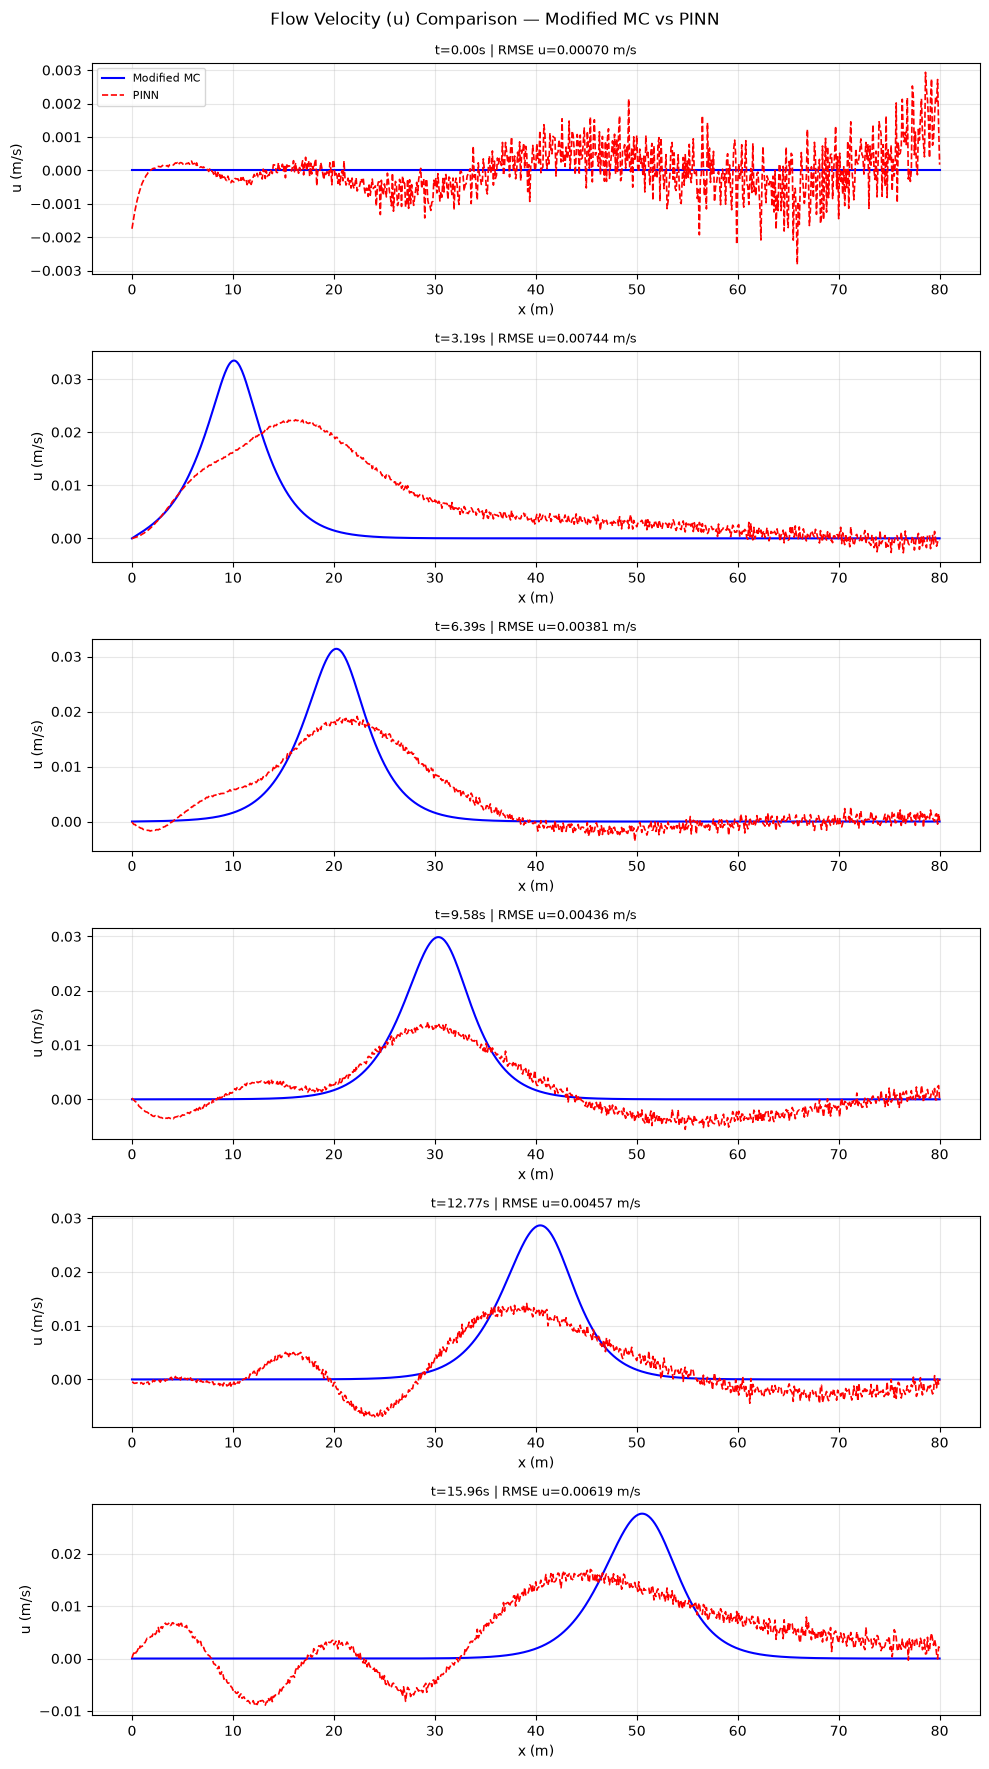

In [14]:
plot_comparison_u_undular(
    results_mc = results_mc,
    u_model    = u_model,
    x_num      = x_num,
    times      = save_times,
    save_path  = os.path.join(fig_dir, "hybrid_pinn_u.png")
)